## Assignment 1 – Data Preparation (UCI Bank Marketing)

GitHub:

This notebook documents the full data preparation process for the UCI Bank Marketing dataset (bank-additional.csv).  

The goal of this assignment is not to build the most accurate model, but to show that the data is prepared correctly and that no data leakage occurs at any stage.  

Each step follows a deliberate order to reflect how a real machine learning pipeline should be structured.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.utils import resample

RANDOM_STATE = 42
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_theme(style='whitegrid')

### Task Ordering and Pipeline Discipline

Although the assignment lists tasks alphabetically, they cannot be executed in that order. In machine learning, the sequence of operations matters because certain steps learn parameters from the data.

I follow this order:

1. Identify the prediction target.
2. Inspect and explore the full dataset (without fitting any transformations).
3. Apply structural cleaning that does not estimate parameters (e.g., dropping duration, handling sentinel values).
4. Split the dataset into training, validation, and test sets.
5. Perform all stateful transformations (imputation, encoding, scaling, feature selection) using the training set only.
6. Apply those learned transformations to validation and test sets.
7. Address class imbalance using training data only.
8. Train a Logistic Regression model as a consistency check.
9. Evaluate performance on the validation set.

Any deviation from this order risks data leakage. A few examples of what goes wrong if splitting happens too late:

Scaling before splitting: the scaler would be fitted on the full dataset, so its mean and standard deviation include validation and test observations. When those sets get scaled using those same statistics, the model has indirectly seen them already.

Imputation before splitting: the median used to fill missing pdays values would be computed from all rows, not just training. This means the imputed value is slightly influenced by the held-out data, which shouldn't be the case.

Resampling before splitting: duplicated minority observations created from the full dataset could end up in both training and validation. The model would then be evaluated on observations it already trained on, which makes recall and precision look better than they really are.

In all three cases the evaluation metrics become unreliable because the held-out sets were never truly unseen.

## Step 1 – Identifying the Prediction Target

The prediction target in this dataset is the variable y, which indicates whether a client subscribed to a term deposit (yes) or not (no). This directly reflects the business objective of the campaign: predicting subscription decisions based on information available at the time of contact.

It is important to clarify why certain other variables cannot be used as the target.

First, duration (the length of the last call) cannot be used because it is only known after the call has already happened. Since the model is meant to help decide whether to contact a client in the first place, using duration would introduce temporal leakage. It would make the model unrealistically accurate but unusable in practice.

Second, campaign (number of contacts during the campaign) is influenced by the outcome itself. Clients who appear uninterested may be contacted more frequently, meaning the variable partly reflects the final decision. Treating it as a target would mix cause and effect.

Third, pdays (days since last contact) does not represent a campaign outcome. The value 999 indicates that the client was never previously contacted, which is not a true numerical measurement but a coded category. For this reason, it is not meaningful as a prediction objective. However, it can still be useful as a feature once handled correctly.

For these reasons, y is the only valid target variable for this task.


## Step 2 – Data Loading and Exploration


In [ ]:
df_raw = pd.read_csv('bank-additional (3).csv', sep=';')

print(f'dataset shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'memory usage  : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
df_raw.head()

dataset shape : 4,119 rows × 21 columns
memory usage  : 2745.3 KB


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [ ]:
num_cols_raw = df_raw.select_dtypes(include='number').columns.tolist()
cat_cols_raw = [c for c in df_raw.columns if c not in num_cols_raw]

print('numerical variables:', num_cols_raw)
print()
print('categorical variables:', cat_cols_raw)

numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [ ]:
df_raw[num_cols_raw].describe().round(3)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000
mean,40.114,256.788,2.537,960.422,0.190,0.085,93.580,-40.499,3.621,5166.482
std,10.313,254.704,2.568,191.923,0.542,1.563,0.579,4.595,1.734,73.668
min,18.000,0.000,1.000,0.000,0.000,-3.400,92.201,-50.800,0.635,4963.600
25%,32.000,103.000,1.000,999.000,0.000,-1.800,93.075,-42.700,1.334,5099.100
50%,38.000,181.000,2.000,999.000,0.000,1.100,93.749,-41.800,4.857,5191.000
75%,47.000,317.000,3.000,999.000,0.000,1.400,93.994,-36.400,4.961,5228.100
max,88.000,3643.000,35.000,999.000,6.000,1.400,94.767,-26.900,5.045,5228.100


In [ ]:
target_vc = df_raw['y'].value_counts()
target_pct = df_raw['y'].value_counts(normalize=True).mul(100).round(1)
print('target variable distribution:')
print(pd.DataFrame({'Count': target_vc, 'Percentage (%)': target_pct}))
print(f'\nimbalance ratio (majority:minority) ≈ {target_vc["no"]/target_vc["yes"]:.1f}:1')

target variable distribution:
     Count  Percentage (%)
y                         
no    3668            89.1
yes    451            10.9

imbalance ratio (majority:minority) ≈ 8.1:1


The dataset is strongly imbalanced: around 89% of clients did not subscribe, while only about 11% did. This gives an imbalance ratio of roughly 8:1.

Because of this, a model that always predicts “no” would already achieve high accuracy. Therefore, accuracy by itself would be misleading, and the minority class needs special attention during training.

In [ ]:
explicit_na = df_raw.isnull().sum()
print('explicit NaN values per column:')
print(explicit_na[explicit_na > 0] if explicit_na.sum() > 0 else '  None found.')

print('\nimplicit missing values ("unknown" category):')
for col in cat_cols_raw:
    n = (df_raw[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:<15}: {n:>4} ({100*n/len(df_raw):.1f}%)')

n_999 = (df_raw['pdays'] == 999).sum()
print(f'\nsentinel value pdays == 999: {n_999} ({100*n_999/len(df_raw):.1f}%)')

explicit NaN values per column:
  None found.

implicit missing values ("unknown" category):
  job            :   39 (0.9%)
  marital        :   11 (0.3%)
  education      :  167 (4.1%)
  default        :  803 (19.5%)
  housing        :  105 (2.5%)
  loan           :  105 (2.5%)

sentinel value pdays == 999: 3959 (96.1%)


### Findings

There are no explicit missing values in the dataset.

However, several categorical variables contain the label "unknown", which effectively represents missing information. The column most affected is default (about 19.5%), while education, housing, loan, job, and marital also contain smaller proportions.

Rather than removing these rows, I keep "unknown" as its own category. Dropping them would reduce the dataset size unnecessarily, and the fact that a client chose not to disclose information (for example about default status) may itself carry useful signal.

The variable pdays uses the value 999 to indicate that the client was never previously contacted. This is not a true numeric value but a coded category, so it needs to be handled separately during preprocessing.

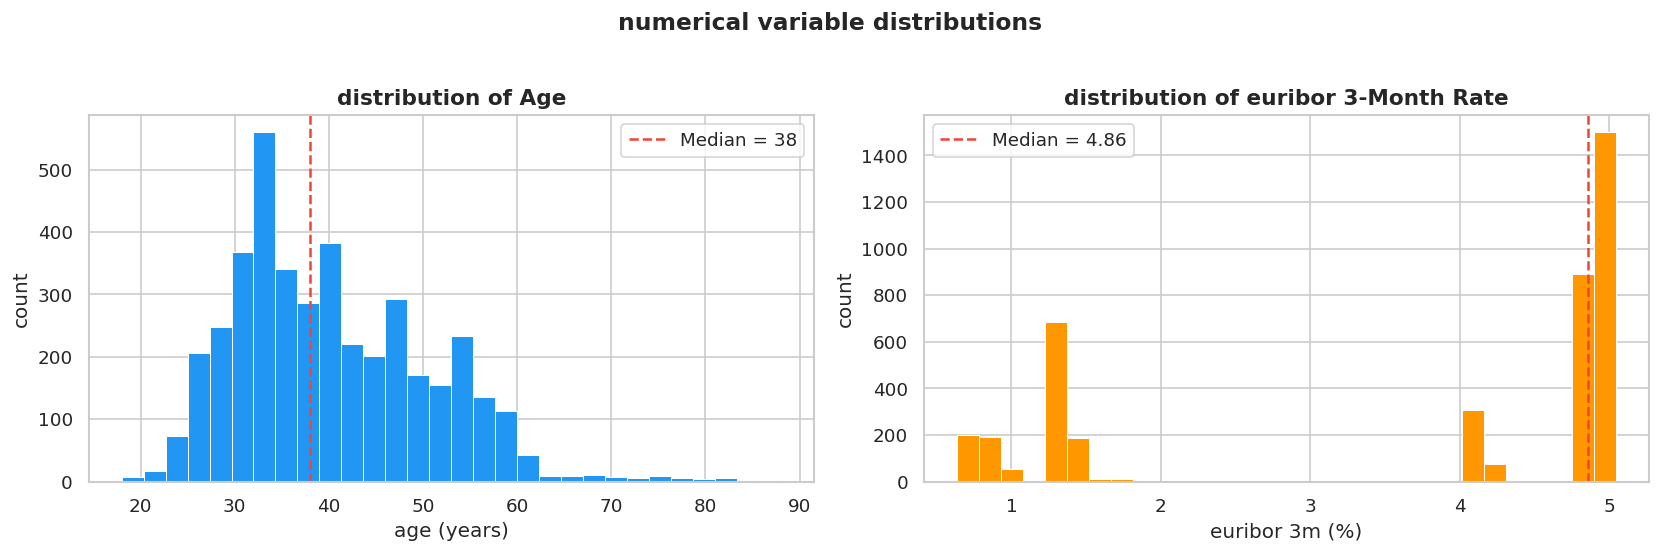

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(df_raw['age'], bins=30, color='#2196F3', edgecolor='white', linewidth=0.6)
axes[0].set_title('distribution of Age', fontweight='bold', fontsize=13)
axes[0].set_xlabel('age (years)')
axes[0].set_ylabel('count')
axes[0].axvline(df_raw['age'].median(), color='#F44336', linestyle='--', linewidth=1.5, label=f'Median = {df_raw["age"].median():.0f}')
axes[0].legend()

axes[1].hist(df_raw['euribor3m'], bins=30, color='#FF9800', edgecolor='white', linewidth=0.6)
axes[1].set_title('distribution of euribor 3-Month Rate', fontweight='bold', fontsize=13)
axes[1].set_xlabel('euribor 3m (%)')
axes[1].set_ylabel('count')
axes[1].axvline(df_raw['euribor3m'].median(), color='#F44336', linestyle='--', linewidth=1.5,
                label=f'Median = {df_raw["euribor3m"].median():.2f}')
axes[1].legend()

plt.suptitle('numerical variable distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The age distribution is approximately bell-shaped, with a slight right skew. Most clients are between 25 and 60 years old, and the median age is 38.

The Euribor 3-month rate shows a clearly bimodal pattern. Values cluster around two main ranges (roughly near 1% and near 5%), which likely reflect different economic periods during which the campaign data was collected.

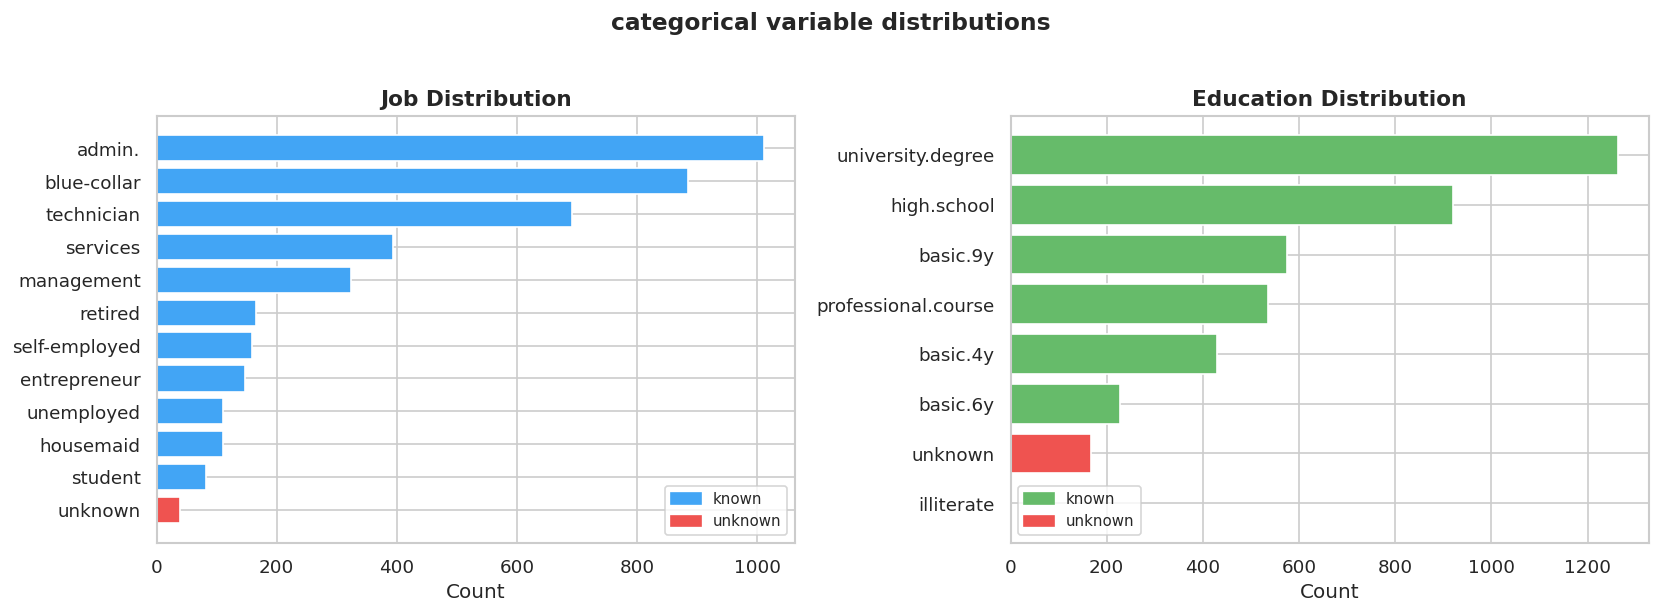

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

job_vc = df_raw['job'].value_counts()
colors_job = ['#EF5350' if v == 'unknown' else '#42A5F5' for v in job_vc.index]
axes[0].barh(job_vc.index[::-1], job_vc.values[::-1], color=colors_job[::-1])
axes[0].set_title('Job Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Count')
red_patch = mpatches.Patch(color='#EF5350', label='unknown')
blue_patch = mpatches.Patch(color='#42A5F5', label='known')
axes[0].legend(handles=[blue_patch, red_patch], fontsize=9)

edu_vc = df_raw['education'].value_counts()
colors_edu = ['#EF5350' if v == 'unknown' else '#66BB6A' for v in edu_vc.index]
axes[1].barh(edu_vc.index[::-1], edu_vc.values[::-1], color=colors_edu[::-1])
axes[1].set_title('Education Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Count')
red_patch2 = mpatches.Patch(color='#EF5350', label='unknown')
green_patch = mpatches.Patch(color='#66BB6A', label='known')
axes[1].legend(handles=[green_patch, red_patch2], fontsize=9)

plt.suptitle('categorical variable distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The job distribution is concentrated in a few categories, particularly admin., blue-collar, and technician. Only a small number of observations are labelled as "unknown".

For education, university degree and high school are the most common levels. A small proportion of entries are marked as "unknown", which will be treated as a separate category during encoding rather than being dropped.

### Variables Requiring Special Consideration

A few variables require extra attention before modelling.

The variable duration cannot be used because it is only known after a call has taken place. Since the goal is to predict whether a client will subscribe before making the call, including duration would introduce temporal leakage. For that reason, it is removed before any modelling steps.

The variable pdays contains the value 999 for clients who were never previously contacted. This is not a true numerical measurement but a coded category. Treating 999 as a regular number would distort the scale. To handle this, I replace 999 with NaN and create a binary indicator (pdays_contacted) to distinguish between previously contacted and never contacted clients.

Finally, the macroeconomic variables emp.var.rate, euribor3m, and nr.employed likely capture related economic conditions. Because they may be highly correlated, this will be checked later using the training set correlation matrix. If strong multicollinearity is confirmed, redundant variables will be removed.

## Step 3 – Managing Missing Values (Pre-Split Structural Cleaning)

At this stage, I apply only structural changes that do not estimate any parameters from the data.

First, duration is removed. This variable is recorded after the call takes place, so it would not be available at prediction time. Keeping it would introduce temporal leakage and make the model unrealistically accurate.

Next, I handle the pdays variable. The value 999 indicates that the client was never previously contacted. Since this is not a real numeric value but a coded category, I replace 999 with NaN. I also create a binary variable (pdays_contacted) to distinguish between clients who were previously contacted and those who were not.

Finally, I convert the target variable y into a binary format (1 for "yes", 0 for "no") to prepare it for modelling.

These changes are structural and do not rely on dataset statistics, so they can safely be performed before splitting the data.

In [ ]:
df = df_raw.copy()
df.drop(columns=['duration'], inplace=True)
print('dropped "duration" not available at prediction time.')

df['pdays_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, np.nan)
print('created "pdays_contacted" indicator (1 = was contacted before, 0 = never).')
print('replaced pdays sentinel 999 → NaN.')
df['y'] = (df['y'] == 'yes').astype(int)
print('target encoded: yes = 1, no = 0.')

print(f'\ndataset shape after pre split cleaning: {df.shape}')

dropped "duration" not available at prediction time.
created "pdays_contacted" indicator (1 = was contacted before, 0 = never).
replaced pdays sentinel 999 → NaN.
target encoded: yes = 1, no = 0.

dataset shape after pre split cleaning: (4119, 21)


### Post-Split Missingness Strategy

After splitting the data, any operation that estimates a value from the data must use the training set only.

For pdays, I replace the 999 sentinel with NaN and then fill missing values using the median computed from the training set. The same median is then applied to the validation and test sets. This ensures that no information from the validation or test data influences the imputed value.

For categorical variables such as job, marital, education, housing, loan, and default, the label "unknown" is kept as its own category. Since this does not involve estimating any statistics, it does not introduce leakage.

I avoid dropping rows with "unknown" because doing so would remove a large portion of the data and potentially discard useful signal. In particular, non-disclosure (for example in default) may itself carry predictive information.

## Step 4 – Data Splitting

The dataset is split into training, validation, and test sets using a 70/15/15 proportion.

With 4,119 observations, this results in approximately 2,883 rows for training and about 618 rows each for validation and testing. The training set is large enough to estimate scaling, encoding, and imputation parameters reliably. The validation set is used to check whether the pipeline behaves as expected. The test set is kept completely untouched and is not used for any intermediate decisions.

Stratification is applied because the target variable is imbalanced (around 11% positive cases). Without stratification, one of the splits could end up with a noticeably different class ratio, making evaluation less reliable. Using stratify=y ensures that the class distribution remains consistent across all three splits.

The split is performed before any stateful transformations (such as scaling or imputation) to prevent data leakage.

In [ ]:
X = df.drop(columns=['y'])
y_series = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_series, test_size=0.30, random_state=RANDOM_STATE, stratify=y_series
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
for split in [X_train, X_val, X_test, y_train, y_val, y_test]:
    split.reset_index(drop=True, inplace=True)

print(f'{"split":<12} {"rows":>6} {"positive %":>12}')
print('-' * 32)
for name, Xs, ys in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    print(f'{name:<12} {len(Xs):>6,} {ys.mean()*100:>11.1f}%')

split          rows   positive %
--------------------------------
Train         2,883        11.0%
Validation      618        11.0%
Test            618        10.8%


The class ratio is preserved across all three splits (11% positive in each), confirming that stratification worked correctly.

---
## Step 5 – Managing Missing Values (Post-Split Imputation)

In [ ]:
pdays_median = X_train['pdays'].median()

pdays_median

X_train['pdays'] = X_train['pdays'].fillna(pdays_median)
X_val['pdays']   = X_val['pdays'].fillna(pdays_median)
X_test['pdays']  = X_test['pdays'].fillna(pdays_median)

(X_train['pdays'].isnull().sum(), X_val['pdays'].isnull().sum(),X_test['pdays'].isnull().sum())

(np.int64(0), np.int64(0), np.int64(0))

The median of pdays is computed using the training set only and applied to the validation and test sets.

After imputation, no missing values remain in pdays. Using the training-set median prevents information from the validation or test sets from influencing the imputation value.

## Step 6 – Encoding Categorical Variables

### Identifying Categorical Variables

In [ ]:
cat_features = []
for c in X_train.columns:
    try:
        X_train[c].str.lower()
        cat_features.append(c)
    except AttributeError:
        pass
print('categorical features to encode:', cat_features)

categorical features to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Encoding Categorical Variables

The dataset contains both nominal and ordinal categorical variables, so different encoding approaches are used.

Most categorical variables (such as job, marital, contact, month, day_of_week, poutcome, default, housing, and loan) do not have a natural ordering. For these variables, I use one-hot encoding. This allows the model to assign a separate coefficient to each category without implying any artificial ranking.

| Variable | Type | Justification |
|----------|------|---------------|
| `job` | Nominal | No meaningful order between professions |
| `marital` | Nominal | Single, married, divorced have no natural rank |
| `contact` | Nominal | Cellular vs telephone — two unordered categories |
| `month` | Nominal | Months here label campaign periods, not a true sequence |
| `day_of_week` | Nominal | Days encode scheduling patterns, not a rank |
| `poutcome` | Nominal | Failure, nonexistent, success have no cardinal order |
| `default` | Nominal | No/unknown/yes — unordered categorical |
| `housing` | Nominal | Yes/no/unknown — unordered |
| `loan` | Nominal | Yes/no/unknown — unordered |
| `education` | Ordinal | Clear progression: illiterate -> basic -> high school -> university degree |

Education is treated as ordinal and encoded using an integer mapping that reflects the natural progression shown in the table above.

When applying one-hot encoding, one column per variable is dropped (drop_first=True) to avoid perfect multicollinearity. The encoding is fitted on the training set only, and the validation and test sets are aligned to the same column structure.

The category "unknown" is kept as its own level. Although it does not represent a true education level, it may capture behavioural differences related to non-disclosure.

In [ ]:
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y','high.school', 'professional.course', 'university.degree', 'unknown']
edu_map = {cat: i for i, cat in enumerate(education_order)}
print(edu_map)

for split in [X_train, X_val, X_test]:
    split['education'] = split['education'].map(edu_map)

{'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3, 'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 7}


In [ ]:
nominal_cols = [c for c in cat_features if c != 'education']
print(nominal_cols)

X_train_enc = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=int)

X_val_enc  = pd.get_dummies(X_val,  columns=nominal_cols, drop_first=True, dtype=int)
X_test_enc = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=int)
train_cols = X_train_enc.columns.tolist()
X_val_enc  = X_val_enc.reindex(columns=train_cols, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=train_cols, fill_value=0)

print(f'\ndimensionality before encoding : {X_train.shape[1]}')
print(f'dimensionality after  encoding : {X_train_enc.shape[1]}')
print(f'new columns added: {X_train_enc.shape[1] - X_train.shape[1]}')

['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

dimensionality before encoding : 20
dimensionality after  encoding : 47
new columns added: 27


### Effect of Encoding on the Model

Applying one-hot encoding increases the number of features. In this case, the feature space grows from 20 to 47 columns. Each category level (except the reference level) becomes its own binary column. This makes the dataset wider but allows the model to treat each category separately.

With one-hot encoding, each category receives its own coefficient in Logistic Regression. This makes interpretation straightforward: the coefficient shows how belonging to that category changes the log-odds of subscription relative to the reference category.

Without encoding, assigning arbitrary integers to nominal variables like `job` would incorrectly impose an ordering. One-hot encoding avoids that issue by treating categories independently.

## Step 7 – Feature Scaling

Continuous numerical variables are scaled using standardisation. Binary indicator variables (such as one-hot encoded columns and pdays_contacted) are already on a 0–1 scale and do not require scaling. The ordinal education variable is also included in scaling so that it is on a comparable scale to the other numeric features.

Standardisation transforms each feature to have mean 0 and standard deviation 1. The parameters (mean and standard deviation) are computed using the training set only, and the same transformation is applied to validation and test sets.

Scaling is important for Logistic Regression because the model uses gradient-based optimisation. If features are on very different scales, some coefficients may dominate simply due to their units. Standardisation ensures that all features contribute on a comparable scale and that the regularisation penalty treats them fairly.

Min max scaling was not used because it is more sensitive to extreme values. Standardisation is generally more stable for this type of model.

In [ ]:
binary_cols = [c for c in X_train_enc.columns if X_train_enc[c].nunique() == 2 and X_train_enc[c].min() == 0]
scale_cols  = [c for c in X_train_enc.columns if c not in binary_cols]

print(f'columns to scale ({len(scale_cols)}): {scale_cols}')
print(f'binary columns skipped ({len(binary_cols)}): {binary_cols[:8]} ...' if len(binary_cols)>8 else f'binary columns skipped: {binary_cols}')

columns to scale (10): ['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
binary columns skipped (37): ['pdays_contacted', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services'] ...


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train_enc[scale_cols])
X_train_scaled = X_train_enc.copy()
X_val_scaled   = X_val_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.transform(X_train_enc[scale_cols])
X_val_scaled[scale_cols]   = scaler.transform(X_val_enc[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test_enc[scale_cols])

means  = X_train_scaled[scale_cols].mean().round(6)
stdevs = X_train_scaled[scale_cols].std().round(4)
print(means.values)
print(stdevs.values)

[-0. nan -0.  0.  0. -0. -0.  0. -0.  0.]
[1.0002    nan 1.0002 1.0002 1.0002 1.0002 1.0002 1.0002 1.0002 1.0002]


## Step 8 – Feature Selection

Feature selection is performed using the training set only. Any statistics used to decide which features to remove (such as variance or correlation) must not be computed on the full dataset, since that would allow information from the validation or test sets to influence the model.

### Low-Variance Features

After scaling, most continuous variables have variance close to 1. If a feature has very low variance on the training set (below 0.01), it means that it barely changes across observations and is unlikely to contribute meaningful information. Such near-constant features are removed.

The threshold is intentionally small so that only features with almost no variation are dropped.


In [ ]:
train_variance = X_train_scaled.var()

VAR_THRESHOLD = 0.01
low_var_cols = train_variance[train_variance < VAR_THRESHOLD].index.tolist()
print(f'low-variance features (variance < {VAR_THRESHOLD}) computed on training set:')
if low_var_cols:
    print(pd.DataFrame({'variance': train_variance[low_var_cols].round(6)}))
else:
    print('  none found.')
print(f'\ntotal variance stats (training):')
print(train_variance.sort_values().head(10).round(5))

low-variance features (variance < 0.01) computed on training set:
                 variance
job_unknown      0.008599
marital_unknown  0.002423
default_yes      0.000347
month_dec        0.005864

total variance stats (training):
default_yes        0.00035
marital_unknown    0.00242
month_dec          0.00586
job_unknown        0.00860
month_mar          0.01064
month_sep          0.01571
month_oct          0.01805
job_student        0.01805
loan_unknown       0.02205
housing_unknown    0.02205
dtype: float64


In [ ]:
train_variance = X_train_scaled.var()
VAR_THRESHOLD  = 0.01

low_var_cols = train_variance[train_variance < VAR_THRESHOLD].index.tolist()
default_cols = [c for c in X_train_scaled.columns if 'default' in c]
for c in default_cols:
    if X_train_scaled[c].var() < VAR_THRESHOLD and c not in low_var_cols:
        low_var_cols.append(c)

print(f'low-variance columns to drop (variance < {VAR_THRESHOLD} on training set):')
if low_var_cols:
    print(train_variance[low_var_cols].round(6).to_string())
else:
    print('  none found.')

low-variance columns to drop (variance < 0.01 on training set):
job_unknown        0.008599
marital_unknown    0.002423
default_yes        0.000347
month_dec          0.005864


In [ ]:
if low_var_cols:
    X_train_scaled.drop(columns=low_var_cols, inplace=True)
    X_val_scaled.drop(columns=low_var_cols, inplace=True)
    X_test_scaled.drop(columns=low_var_cols, inplace=True)
    print(f'dropped {len(low_var_cols)} low-variance columns: {low_var_cols}')
else:
    print('no lowvariance columns to drop.')
print(f'{X_train_scaled.shape}')

dropped 4 low-variance columns: ['job_unknown', 'marital_unknown', 'default_yes', 'month_dec']
(2883, 43)


### Highly Correlated Features

Next, I examine correlations among the continuous variables using the training set. When two features are highly correlated, they carry very similar information. Keeping both can make coefficient estimates unstable in a linear model.

If strong correlations are detected (above the chosen threshold), one of the redundant variables is removed. This helps simplify the model and reduce multicollinearity, while keeping the most interpretable variable where possible.

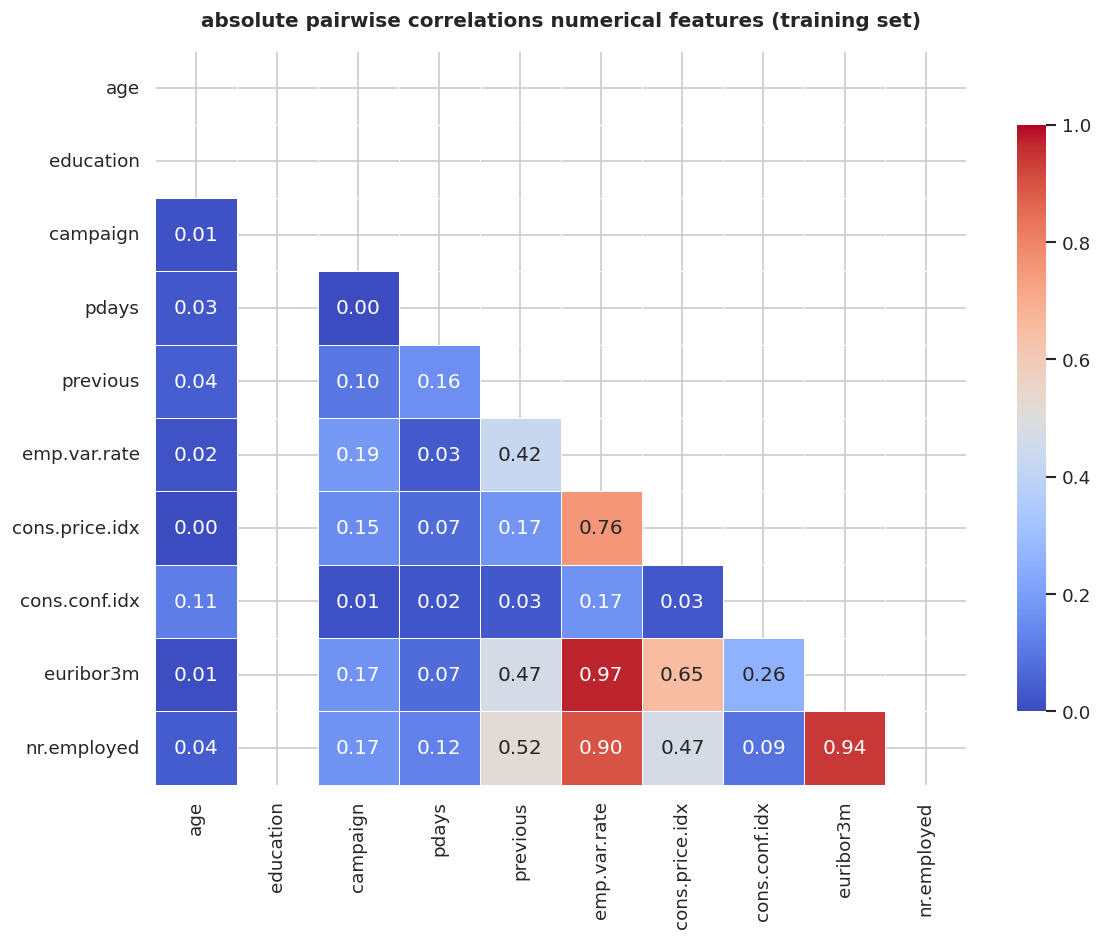

In [ ]:
cont_cols_for_corr = [c for c in scale_cols if c in X_train_scaled.columns]
corr_matrix = X_train_scaled[cont_cols_for_corr].corr().abs()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('absolute pairwise correlations numerical features (training set)',
             fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
CORR_THRESHOLD = 0.90
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if pd.notna(upper_tri.loc[row, col]) and upper_tri.loc[row, col] >= CORR_THRESHOLD
]

print(f'feature pairs with |correlation| ≥ {CORR_THRESHOLD}:')
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {f1:<20} ↔  {f2:<20}: r = {r:.3f}')

feature pairs with |correlation| ≥ 0.9:
  euribor3m            ↔  emp.var.rate        : r = 0.970
  nr.employed          ↔  euribor3m           : r = 0.942


### Correlation-Based Feature Removal

The correlation matrix shows that emp.var.rate, euribor3m, and nr.employed are strongly correlated. Since these variables reflect similar economic conditions, keeping all of them would introduce redundancy.

Highly correlated predictors can make coefficient estimates unstable in a linear model, since the model struggles to separate their individual contributions. To simplify the model, I retain emp.var.rate and remove euribor3m and nr.employed.

The decision is partly practical: emp.var.rate is more directly interpretable as an indicator of economic conditions, while the other two variables capture related information.

In [ ]:
corr_drop = ['euribor3m', 'nr.employed']
corr_drop = [c for c in corr_drop if c in X_train_scaled.columns]

X_train_scaled.drop(columns=corr_drop, inplace=True)
X_val_scaled.drop(columns=corr_drop, inplace=True)
X_test_scaled.drop(columns=corr_drop, inplace=True)

print(f'{corr_drop}')
print(f'final feature set size: {X_train_scaled.shape[1]}')
print(f'final training shape:{X_train_scaled.shape}')

[]
final feature set size: 41
final training shape:(2883, 41)


Both the variance filter and the correlation filter were applied using the training set only. The same columns were then removed from the validation and test sets. At no point were statistics from the held-out sets used to guide feature selection.

---
## Step 9 – Addressing Class Imbalance

### Class Distribution in the Training Set

In [ ]:
n_majority = (y_train == 0).sum()
n_minority = (y_train == 1).sum()
ratio = n_majority / n_minority

print(f'majority (no): {n_majority}, minority (yes): {n_minority}')
print(f'imbalance ratio ≈ {ratio:.1f}:1')

majority (no): 2567, minority (yes): 316
imbalance ratio ≈ 8.1:1


The training set is clearly imbalanced, with roughly eight times more non-subscribers than subscribers.

If left unaddressed, the model could achieve high accuracy simply by predicting the majority class most of the time. However, this would result in very low recall for actual subscribers. Because identifying potential subscribers is more important than maximising raw accuracy, the imbalance needs to be handled during training.

Class imbalance affects different metrics in different ways. Accuracy becomes misleading because a model that always predicts "no" would already score ~89% without learning anything useful. Precision can look deceptively high if the model barely ever predicts positive, since it makes few mistakes on positive predictions simply by making almost none. Recall is the metric that suffers most — an imbalanced model will miss most actual subscribers, which is exactly the outcome the bank wants to avoid.

Random oversampling was chosen over SMOTE because after one-hot encoding the feature space contains many binary columns. SMOTE interpolates between neighbours, which would produce non-integer values in binary columns — for example, 0.3 for a column that should be 0 or 1. This violates the assumption that synthetic samples are realistic. Random oversampling simply duplicates existing minority observations and is always valid. Undersampling was rejected because reducing the majority class to 316 rows would leave only ~632 training samples, too few for stable parameter estimation with 40 features.

One important ordering constraint: resampling must happen after splitting, not before. If oversampling were applied to the full dataset first, duplicate minority observations could end up in both the training and validation sets. The model would then be tested on data it had already seen, making recall and precision look better than they really are. This is a form of evaluation leakage and would make the validation results unreliable.

In [ ]:
train_combined = X_train_scaled.copy()
train_combined['y'] = y_train.values

train_majority = train_combined[train_combined['y'] == 0]
train_minority = train_combined[train_combined['y'] == 1]
train_minority_upsampled = resample(
    train_minority,
    replace=True,
    n_samples=len(train_majority),
    random_state=RANDOM_STATE)

train_resampled = pd.concat([train_majority, train_minority_upsampled])
train_resampled = train_resampled.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_res = train_resampled.drop(columns=['y'])
y_train_res = train_resampled['y']

n_majority_res = (y_train_res == 0).sum()
n_minority_res = (y_train_res == 1).sum()

print(f'Class distribution after oversampling: {n_majority_res} majority, {n_minority_res} minority')
print(f'Training set size: {len(X_train_res)} rows (was {len(X_train_scaled)} before resampling)')
print(f'Validation / Test sets unchanged: {len(X_val_scaled)} / {len(X_test_scaled)} rows')

Class distribution after oversampling: 2567 majority, 2567 minority
Training set size: 5134 rows (was 2883 before resampling)
Validation / Test sets unchanged: 618 / 618 rows


After oversampling, the training set is balanced, with equal numbers of majority and minority cases.

Only the training data is resampled. The validation and test sets are left unchanged to ensure that evaluation reflects the original class distribution.

## Step 10 – Training a Logistic Regression Model

### Why Logistic Regression?

Logistic Regression is used here mainly to check that the data pipeline is working correctly. It is a simple and stable model, so if the preprocessing steps have been implemented properly (encoding, scaling, resampling on the training set only), the model should train without issues and produce reasonable coefficients.

The goal at this stage is not to optimise performance, but to confirm that the pipeline behaves as expected.

In [ ]:
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

X_train_res = X_train_res.fillna(0)
X_val_scaled = X_val_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

lr.fit(X_train_res, y_train_res)
y_pred_val = lr.predict(X_val_scaled)


In [ ]:
acc  = accuracy_score(y_val, y_pred_val)
prec = precision_score(y_val, y_pred_val, zero_division=0)
rec  = recall_score(y_val, y_pred_val, zero_division=0)

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

# Fitted on original (imbalanced) labels correctly reflects real-world class distribution
dummy.fit(X_train_scaled, y_train)

y_dummy_val = dummy.predict(X_val_scaled)

dummy_acc  = accuracy_score(y_val, y_dummy_val)
dummy_prec = precision_score(y_val, y_dummy_val, zero_division=0)
dummy_rec  = recall_score(y_val, y_dummy_val, zero_division=0)

zero_rule = dummy_acc

In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    'Model'    : ['Zero-Rule (always predict majority)', 'Logistic Regression'],
    'Accuracy' : [dummy_acc,  acc],
    'Precision': [dummy_prec, prec],
    'Recall'   : [dummy_rec,  rec],
})
print("validation performance:")
print(comparison.round(3).to_string(index=False))

validation performance:
                              Model  Accuracy  Precision  Recall
Zero-Rule (always predict majority)      0.89      0.000   0.000
                Logistic Regression      0.83      0.352   0.647


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_val, y_pred_val)
print(f"{f1:.3f}")

0.456


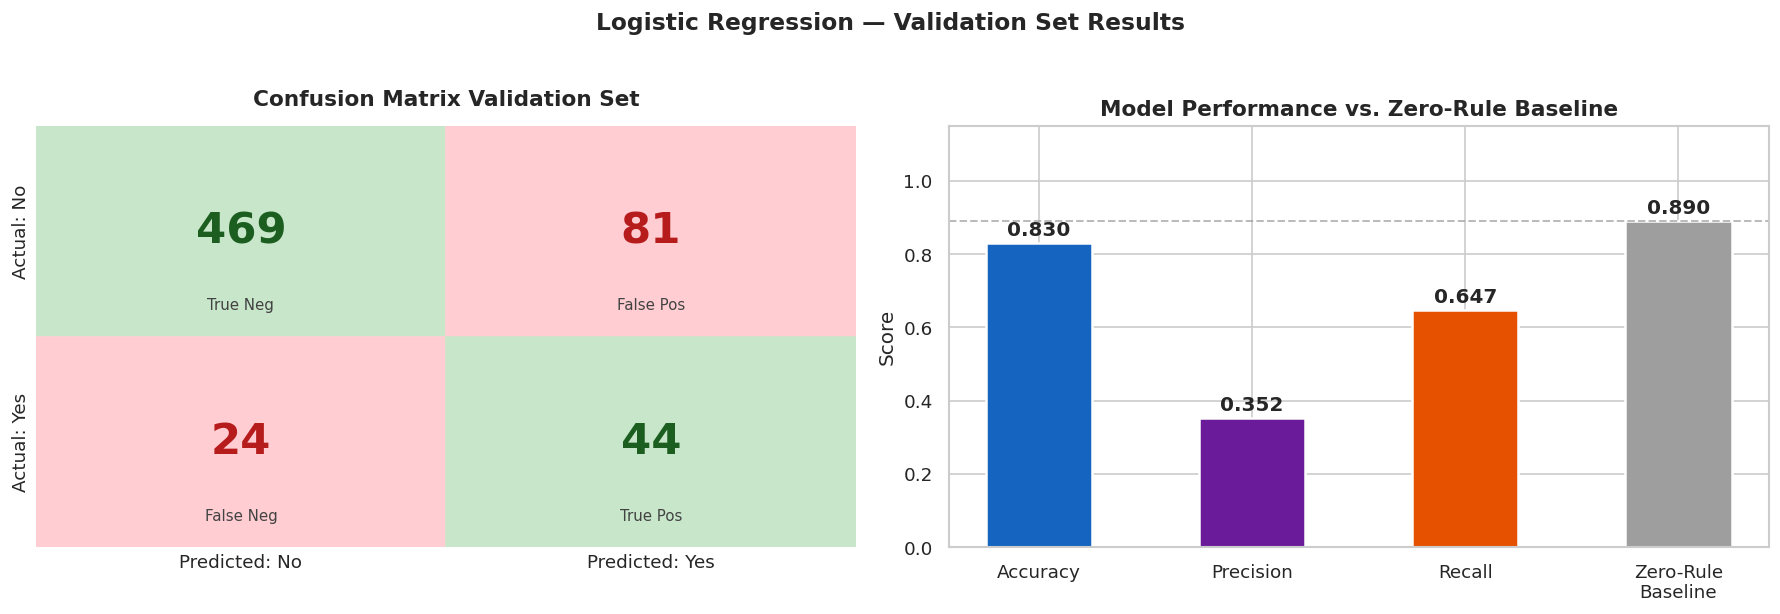

In [ ]:
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
cell_colours = np.array([['#C8E6C9', '#FFCDD2'],
                          ['#FFCDD2', '#C8E6C9']])
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, color=cell_colours[i, j]))
        ax.text(j + 0.5, 1.5 - i, str(cm[i, j]),
                ha='center', va='center', fontsize=26, fontweight='bold',
                color='#1B5E20' if i == j else '#B71C1C')
        label = ['True Neg', 'False Pos', 'False Neg', 'True Pos'][(i*2)+j]
        ax.text(j + 0.5, 1.15 - i, label,
                ha='center', va='center', fontsize=9, color='#424242')

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Predicted: No', 'Predicted: Yes'], fontsize=11)
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Actual: Yes', 'Actual: No'], fontsize=11, rotation=90, va='center')
ax.set_title('Confusion Matrix Validation Set', fontweight='bold', fontsize=13, pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values(): spine.set_visible(False)

ax2 = axes[1]
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'Zero-Rule\nBaseline']
metrics_values = [acc, prec, rec, zero_rule]
bar_colours    = ['#1565C0', '#6A1B9A', '#E65100', '#9E9E9E']

bars = ax2.bar(metrics_names, metrics_values, color=bar_colours, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metrics_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylim(0, 1.15)
ax2.set_title('Model Performance vs. Zero-Rule Baseline', fontweight='bold', fontsize=13)
ax2.set_ylabel('Score')
ax2.axhline(y=zero_rule, color='#9E9E9E', linestyle='--', linewidth=1.2, alpha=0.7)

plt.suptitle('Logistic Regression — Validation Set Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretation of Results

The Zero-Rule baseline achieves 89% accuracy but 0% recall, since it always predicts the majority class (“no”). While this produces high accuracy, it completely fails to identify subscribers.

After oversampling, Logistic Regression achieves 83.0% accuracy, 35.2% precision, and 64.7% recall on the validation set.

From the confusion matrix:
- 44 subscribers are correctly identified (true positives).
- 24 subscribers are missed (false negatives).
- 81 non-subscribers are incorrectly classified as subscribers (false positives).

The drop in accuracy compared to the Zero-Rule baseline is expected. The model is now actively predicting the minority class instead of ignoring it, which increases false positives but substantially improves recall.

In this context, recall is more important than raw accuracy, since missing a potential subscriber is more costly than making an additional phone call. Overall, the results suggest that the preprocessing and resampling steps are working as intended.

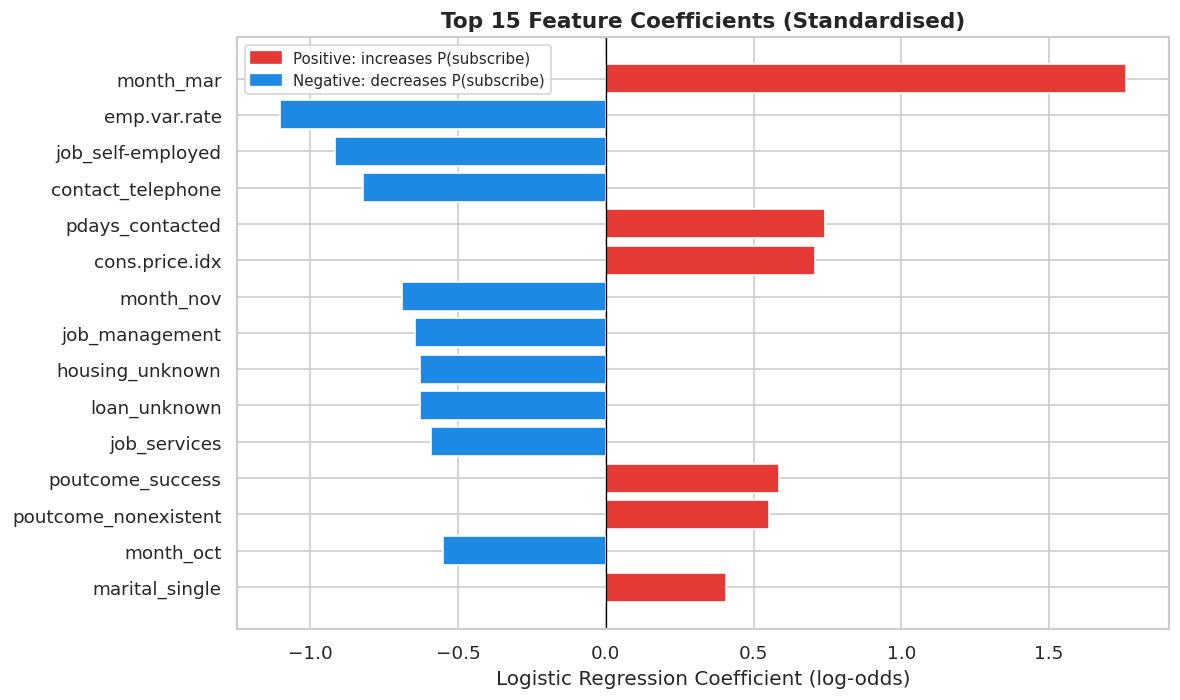

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E53935' if c > 0 else '#1E88E5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (log-odds)')
ax.set_title('Top 15 Feature Coefficients (Standardised)', fontweight='bold', fontsize=13)
red_p  = mpatches.Patch(color='#E53935', label='Positive: increases P(subscribe)')
blue_p = mpatches.Patch(color='#1E88E5', label='Negative: decreases P(subscribe)')
ax.legend(handles=[red_p, blue_p], fontsize=9)
plt.tight_layout()
plt.show()

The coefficients are finite and reasonably scaled, with no extreme values or missing numbers. This suggests that the preprocessing steps (imputation, encoding, scaling, and feature selection) were applied correctly and that the model trained without instability.

## Final Pipeline Overview

The full pipeline follows this sequence:

1. Identify the target variable.
2. Perform structural cleaning (drop duration, handle pdays, encode target).
3. Split the data into training, validation, and test sets.
4. Fit all stateful transformations on the training set only (imputation, encoding, scaling, feature selection).
5. Apply the same transformations to validation and test sets.
6. Address class imbalance using training data only.
7. Train Logistic Regression and evaluate on the validation set.

At no stage are statistics from the validation or test sets used to influence model training. The test set remains untouched and reserved for a final unbiased evaluation.